# Lightglue Auto Georeferencing
## Overview
This project is looking into how to utilize the lightglue network for purposes of georeferencing. Lightglue is a model designed to find common keypoints within two images, and its continuation of the Superglue model. It's main draw is that it is much, much faster. How it's shown to be used in it's examples is fairly straightforward. You have a picture of a location in one angle, and a picture of another location in another angle. The model is designed to find the matches between those two points and give you the pixel coordinates for the match and the confidence of the match.

Here is an image showcase it's intended usecase from ligtglues github https://github.com/cvg/lightglue
![image.png](attachment:24a73449-0074-4ca5-af4c-c19bb8cecb68.png)

The problem our lab was encountering was using the Corona Spy Satellite Imagery for land classification. The imagery was initally physically stored, which means that it was distorted in ways that are unpredictable and has made georeferencing very difficult. The graduate I worked with told me that for a single quarter of corona imagery tried to manually georeference it with about 100 GCP's, and unfortunately was unable to get it to work well. Furthermore, ArcGIS Pro's automatic georeferencing wasn't very good

So we decided to do our own. The model works suprisingly well for satellite imagery, generating many accurate matches with no false positives in the 90% range. For example, it never matches ocean to ocean, despite the fact that it's basically patterned noise. Furthermore after examining the model, it automatically resamples its data to 1024x1024 and reduces it to black and white. This is amazing because we ONLY have black and white imagery.

## Workflow
1. Obtain .tif of corona section interested in and load into ArcGIS Pro
2. Roughly georeference corona section with ArcGIS Pro basemap, using the location from the data downloader as reference. 4-5 GCP's should be good, the point of this is that most of the work should be done through the model
3. Ultilize XYZ script to download NAIP imagery based off geospatial coordinates of Corona Image, will be buffered by 10% to account for most errors
4. Utlize overlapping tiles script to create 1024x1024 tiles from corona imagery, utilizing the coordinates of that specfic window to create the bounds of the extracted NAIP imagery. Sections of CORONA that are more than 50% NoData are filtered out.
5. Once both set of tiles are created, run each pair through lightglue. Filter matches greater than 90%, and then using the coordinates of the tile and the image coordinates in relation to the whole tile, create a GCP matching image pixel in the WHOLE CORONA image versus to real world coordinate.
6. Use rasterio to warp image and bam you got your georeferenced image
7. Verify the result: check which tiles actually produced matches, export the collected GCPs for review, and visualize their locations on the corona imagery before trusting the final georeferenced output.


## Active Research Questions
This is a sectiona of active areas I am looking at investigating to improve the workflow
1. Do automated georeferencing then Thin Spline Interpolation
2. Compare ArcGIS Automated Georeferencing
3. Do manual Lightglue model point verification, see where it does well versus where it does bad and catalogue
4. Look into RANSAC(Effectively filtering by estimating geometry)
5. Paper Review and Compare Alternative LoRetta Model
6. Investigate creating a Rigorous Camera Model
    * Corona Uses PANORAMIC Cameras, Sweeping Capture causes more distortion, estimate how the camera would have moved to fix relief displacement
    * Nominal Overlap of 5% @ Nadir, Forward and Aft Camera , DS1117-2086DF001, DS1117-2086DA001, Not neccesarily matching but should be close

7. Modeel Locally Affine Projective Transformation
 * Is done on a per tile basis, enables ransac filtering because you again fit a plane and fit anything that doesn't make a ton of sense.
8. Smoothing Spline instead of Interpolation
    * Bad measurements don't cause as severe error, can filter points that don't fit the smoothing spline


In [1]:
import csv
import shutil
import logging
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
from PIL import Image
import torch

import ee
import geemap

import pyproj
import rasterio
from rasterio._io import Resampling
from rasterio.control import GroundControlPoint
from rasterio.transform import from_gcps, array_bounds, GCPTransformer
from rasterio.warp import transform as warp_transform, transform_bounds
from rasterio.windows import Window, get_data_window, transform as window_transform

from lightglue import LightGlue, SuperPoint, DISK
from lightglue.utils import load_image, rbd, numpy_image_to_torch, resize_image, read_image
from lightglue import match_pair, viz2d

torch.set_grad_enabled(False)
images = Path("assets")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 'mps', 'cpu'

extractor = SuperPoint(max_num_keypoints=2048).eval().to(device)  # load the extractor
matcher = LightGlue(features="superpoint").eval().to(device)


## Configuration
Path and parameter values used throughout the notebook. `corona_source_path` and `naip_source_path` were previously configured separately (and inconsistently) between `GEEData.py` and `georeferencing.py` - both scripts are unified here to operate on the same pair of files.

In [10]:
# Roughly georeferenced corona coverage image, produced manually in ArcGIS Pro (steps 1-2)
corona_source_path = "data/source/CoronaCoverage.tif"

# NAIP mosaic downloaded from Earth Engine in step 3, matched to corona_source_path's extent
naip_source_path = "data/source/NAIPCoverage.tif"

tile_size = 1024
tiles_dir = Path("data/tiles")
georef_dir = Path("data/results")

confidence_threshold = 0.98
min_gcps = 3

# Bucket thinning grid, in corona pixels (~3.29 m/px), so 300 px is roughly 1 km.
# Set to 0 to skip thinning and fit on every GCP.
thinning_cell_size = 300

ee_project = "graphic-height-476615-k5"
region_padding_fraction = 0.05  # pads the NAIP download region by this fraction on each side
target_date_str = "2003-06-01"  # NAIP acquisition date to prioritize when multiple years are available

# Benchmark point csvs - matched lat/long pairs of the same features in corona vs naip
benchmark_corona_csv = "data/benchmark/org_cor_points.csv"
benchmark_naip_csv = "data/benchmark/NAIP_points.csv"
benchmark_moved_csv = "data/benchmark/transformed_cor_points.csv"
benchmark_tps_csv = "data/benchmark/tps_cor_points.csv"


## Function Definitions
All functions used by the workflow steps below, defined once up front.

In [3]:
def show_window(array, title):
    if array.shape[0] == 1:
        plt.imshow(array[0], cmap='gray')
    else:
        plt.imshow(np.moveaxis(array, 0, -1))
    plt.title(title)
    plt.axis('off')
    plt.show()
def displayAllSuperglue(image0, image1, p0, p1):
    # Create figure with two subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Display NAIP image
    axes[0].imshow(image0.permute(1, 2, 0).cpu().numpy())
    axes[0].scatter(p0[:, 0], p0[:, 1], c='red', s=10, marker='o', alpha=0.7)
    axes[0].set_title(f'NAIP ({len(p0)} matches)')
    axes[0].axis('off')

    # Display Corona image
    axes[1].imshow(image1.permute(1, 2, 0).cpu().numpy(), cmap='gray' if image1.shape[0] == 1 else None)
    axes[1].scatter(p1[:, 0], p1[:, 1], c='red', s=10, marker='o', alpha=0.7)
    axes[1].set_title(f'Corona ({len(p1)} matches)')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

def displayConfSuperglue(image0, image1, p0, p1,matches, scores):
    # Create figure with two subplots side by side

    # Display NAIP image
    for(i ) in range(len(p1)):
        if(scores[i].item()>0.95):

            fig, axes = plt.subplots(1, 2, figsize=(16, 8))
            axes[0].imshow(image0.permute(1, 2, 0).cpu().numpy())
            axes[0].scatter(p0[i, 0], p0[i, 1], c='red', s=100, marker='o', alpha=0.7)
            axes[0].set_title(f'NAIP (confidence: {scores[i].item():.3f})')
            axes[0].axis('on')

            # Display Corona image
            axes[1].imshow(image1.permute(1, 2, 0).cpu().numpy())
            axes[1].scatter(p1[i, 0], p1[i, 1], c='red', s=100, marker='o', alpha=0.7)
            axes[1].set_title(f'Corona (confidence: {scores[i].item():.3f})')
            axes[1].axis('on')
            print(f"NAIP   X: w{p0[i, 0].item():.1f}  Y: {p0[i, 1].item():.1f}")
            print(f"Corona X: {p1[i, 0].item():.1f}  Y: {p1[i, 1].item():.1f}")

            plt.tight_layout()
            plt.show()

# Renders every frame displayConfSuperglue would show for one tile pair into a single gif.
# Frames are rendered off-screen and closed immediately - hundreds of open figures would exhaust memory.
def create_conf_gif(image0, image1, p0, p1, scores, output_path, threshold=0.9, duration=500, dpi=60, marker_size=400):
    # A gif frame holds only 256 colours, allocated by pixel population. A small marker is too
    # few pixels to earn a palette slot and gets merged into the nearest grey, so it must be large.
    img0 = image0.permute(1, 2, 0).cpu().numpy()
    img1 = image1.permute(1, 2, 0).cpu().numpy()

    frames = []
    for i in range(len(p1)):
        conf = scores[i].item()
        if conf <= threshold:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(16, 8), dpi=dpi)
        axes[0].imshow(img0)
        axes[0].scatter(p0[i, 0], p0[i, 1], c='red', s=marker_size, marker='o', edgecolors='white', linewidths=1.5)
        axes[0].set_title(f'NAIP (confidence: {conf:.3f})  x={p0[i, 0].item():.1f} y={p0[i, 1].item():.1f}')
        axes[1].imshow(img1)
        axes[1].scatter(p1[i, 0], p1[i, 1], c='red', s=marker_size, marker='o', edgecolors='white', linewidths=1.5)
        axes[1].set_title(f'Corona (confidence: {conf:.3f})  x={p1[i, 0].item():.1f} y={p1[i, 1].item():.1f}')
        fig.tight_layout()

        fig.canvas.draw()
        frames.append(Image.fromarray(np.asarray(fig.canvas.buffer_rgba())).convert('RGB'))
        plt.close(fig)

    if not frames:
        print(f'No matches above {threshold} - no gif written')
        return 0

    frames[0].save(output_path, save_all=True, append_images=frames[1:], duration=duration, loop=0)
    print(f'Wrote {len(frames)} frames to {output_path}')
    return len(frames)

def create_coverage_raster(tile_records, reference_path, output_path, downscale=8):
    """Writes a georeferenced raster covering the same area as reference_path, where each
    known tile footprint is filled blue if it produced GCPs, red if it didn't. Areas that
    were never turned into a tile (e.g. filtered out as mostly nodata) are left black.

    tile_records: list of (bounds, has_gcps) - bounds is a (left, bottom, right, top) tuple
        in reference_path's CRS, has_gcps is True/False.
    downscale: shrinks the output resolution relative to reference_path by this factor,
        since tile-level coverage doesn't need full source resolution.
    """
    with rasterio.open(reference_path) as ref:
        out_height = max(1, ref.height // downscale)
        out_width = max(1, ref.width // downscale)
        out_transform = ref.transform * rasterio.Affine.scale(downscale, downscale)
        crs = ref.crs

    coverage = np.zeros((3, out_height, out_width), dtype=np.uint8)
    blue = np.array([0, 0, 255], dtype=np.uint8)
    red = np.array([255, 0, 0], dtype=np.uint8)

    for bounds, has_gcps in tile_records:
        window = rasterio.windows.from_bounds(*bounds, transform=out_transform)
        row_start = max(0, int(round(window.row_off)))
        row_stop = min(out_height, int(round(window.row_off + window.height)))
        col_start = max(0, int(round(window.col_off)))
        col_stop = min(out_width, int(round(window.col_off + window.width)))

        color = blue if has_gcps else red
        coverage[:, row_start:row_stop, col_start:col_stop] = color[:, None, None]

    meta = {
        'driver': 'GTiff',
        'height': out_height,
        'width': out_width,
        'count': 3,
        'dtype': 'uint8',
        'crs': crs,
        'transform': out_transform,
    }
    with rasterio.open(output_path, 'w', **meta) as dst:
        dst.write(coverage)

# Displays the red/blue coverage raster written by create_coverage_raster
def display_coverage_raster(coveragepath):
    with rasterio.open(coveragepath) as src:
        img = src.read()

    plt.figure(figsize=(16, 8))
    #moveaxis rotates around the bands to make it have the proper format for imshow
    plt.imshow(np.moveaxis(img, 0, -1))
    plt.title('Tile coverage (blue = GCPs found, red = no matches)')
    plt.axis('off')
    plt.show()

def export_gcps_csv(gcps, src_crs, output_path):
    """Writes every GCP's corona pixel coordinates (in the full corona raster) alongside
    the corresponding real-world lat/long to a CSV. gcps are in src_crs (e.g. naip's CRS,
    which is usually a projected CRS in meters, not lat/long), so this reprojects each
    point to EPSG:4326 rather than dumping raw projected coordinates as if they were lat/long.
    """
    xs = [gcp.x for gcp in gcps]
    ys = [gcp.y for gcp in gcps]
    lons, lats = warp_transform(src_crs, 'EPSG:4326', xs, ys)

    with open(output_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['corona_col', 'corona_row', 'longitude', 'latitude'])
        for gcp, lon, lat in zip(gcps, lons, lats):
            writer.writerow([gcp.col, gcp.row, lon, lat])

def display_gcps(gcps, corona_path, downscale=8):
    """Plots the full corona raster (downsampled for display) with every GCP's corona
    pixel location overlaid as a marker."""
    with rasterio.open(corona_path) as src:
        out_height = max(1, src.height // downscale)
        out_width = max(1, src.width // downscale)
        img = src.read(
            out_shape=(src.count, out_height, out_width),
            resampling=Resampling.bilinear
        )

    cols = [gcp.col / downscale for gcp in gcps]
    rows = [gcp.row / downscale for gcp in gcps]

    plt.figure(figsize=(16, 8))
    if img.shape[0] == 1:
        plt.imshow(img[0], cmap='gray')
    else:
        plt.imshow(np.moveaxis(img, 0, -1))
    plt.scatter(cols, rows, c='red', s=10, marker='o', alpha=0.7)
    plt.title(f'{len(gcps)} GCPs on corona imagery')
    plt.axis('off')
    plt.show()

# Reads a Long,Lat csv into (lon, lat) tuples. utf-8-sig strips the BOM these files carry.
def read_points_csv(path):
    with open(path, newline='', encoding='utf-8-sig') as f:
        return [(float(r['Long']), float(r['Lat'])) for r in csv.DictReader(f) if r.get('Long')]

# Writes (lon, lat) tuples back out in the same Long,Lat format
def write_points_csv(path, points):
    with open(path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Long', 'Lat'])
        writer.writerows(points)

# Uses a raster's existing georeferencing to find which (col, row) pixel each lat/long sits on.
# Inverts the affine directly instead of using .index() so the result keeps sub-pixel precision.
def latlon_to_pixels(points, raster_path):
    with rasterio.open(raster_path) as src:
        xs, ys = warp_transform('EPSG:4326', src.crs, [p[0] for p in points], [p[1] for p in points])
        inv = ~src.transform
        return [inv * (x, y) for x, y in zip(xs, ys)]

# Pushes (col, row) pixels through an affine transform into world coords, then out to lat/long
def pixels_to_latlon(pixels, affine_transform, src_crs):
    xs, ys = [], []
    for col, row in pixels:
        x, y = affine_transform * (col, row)
        xs.append(x)
        ys.append(y)
    lons, lats = warp_transform(src_crs, 'EPSG:4326', xs, ys)
    return list(zip(lons, lats))

# Writes where each GCP sits in the CORONA imagery as lat/long, using corona's own
# georeferencing. export_gcps_csv covers the naip-derived side; this is the corona side.
# Output uses the same Long,Lat layout as the benchmark csvs so compare_points can read it.
def export_corona_gcps_latlon(gcps, corona_path, output_path):
    with rasterio.open(corona_path) as src:
        points = pixels_to_latlon([(g.col, g.row) for g in gcps], src.transform, src.crs)
    write_points_csv(output_path, points)
    return points

# Copies a benchmark csv with every point moved through the fitted transform:
# lat/long -> corona pixel (via corona's original georeferencing) -> new world coord -> lat/long
def apply_transform_to_points(in_csv, out_csv, corona_path, affine_transform, dst_crs):
    points = read_points_csv(in_csv)
    pixels = latlon_to_pixels(points, corona_path)
    moved = pixels_to_latlon(pixels, affine_transform, dst_crs)
    write_points_csv(out_csv, moved)
    return moved

# TPS counterpart of pixels_to_latlon. A spline can't be collapsed into a matrix, so this
# builds a GDAL transformer from the gcps instead of multiplying by an affine.
# offset='ul' matters: the default 'center' adds half a pixel (~2.6m here) to every point.
def pixels_to_latlon_tps(pixels, gcps, src_crs):
    with GCPTransformer(gcps, tps=True) as tr:
        xs, ys = tr.xy([p[1] for p in pixels], [p[0] for p in pixels], offset='ul')
    lons, lats = warp_transform(src_crs, 'EPSG:4326', list(xs), list(ys))
    return list(zip(lons, lats))

# TPS counterpart of apply_transform_to_points - takes the gcps themselves rather than a
# fitted transform, since there is no affine to hand over
def apply_tps_to_points(in_csv, out_csv, corona_path, gcps, dst_crs):
    points = read_points_csv(in_csv)
    pixels = latlon_to_pixels(points, corona_path)
    moved = pixels_to_latlon_tps(pixels, gcps, dst_crs)
    write_points_csv(out_csv, moved)
    return moved

# True geodesic separation (meters) between two matched sets of lat/long points, plus summary stats
def compare_points(points_a, points_b, label=''):
    geod = pyproj.Geod(ellps='WGS84')
    dists = np.array([geod.inv(a[0], a[1], b[0], b[1])[2] for a, b in zip(points_a, points_b)])
    print(f'{label} n={len(dists)} mean={dists.mean():.1f}m median={np.median(dists):.1f}m '
          f'min={dists.min():.1f}m max={dists.max():.1f}m rmse={np.sqrt((dists**2).mean()):.1f}m')
    return dists

# Bucket thinning: lay a grid over corona pixel space and keep a single GCP per cell, so a
# densely matched tile can't outweigh a sparsely matched one. Clustered control points make
# a TPS bend sharply between near-duplicate matches, and the solve cost grows cubically.
# Keeps the most confident match per cell when scores are given, else the one nearest the
# cell centre. A cell_size of 0 disables thinning and returns every GCP.
def thin_gcps_bucket(gcps, cell_size, scores=None):
    if cell_size <= 0:
        return list(gcps)

    best = {}
    for i, g in enumerate(gcps):
        key = (int(g.col // cell_size), int(g.row // cell_size))
        if scores is not None:
            rank = scores[i]
        else:
            centre_col = (key[0] + 0.5) * cell_size
            centre_row = (key[1] + 0.5) * cell_size
            rank = -((g.col - centre_col) ** 2 + (g.row - centre_row) ** 2)
        if key not in best or rank > best[key][0]:
            best[key] = (rank, g)

    return [g for _, g in best.values()]

# Plots benchmark residuals over the corona imagery. Each point gets a red dotted line from
# where it started to where the fit moved it, then a second cyan line from there to where it should
# actually be. Unfortunately residuals are tiny compare to the scaled pixel GSD, as a pixel represnts 60m while errors are roughly less than 20m, so that error is artifically increased so it's visible for human comparison.
def display_benchmark_residuals(corona_path, before_points, after_points, truth_points,
                                label='', downscale=8, residual_scale=4):
    with rasterio.open(corona_path) as src:
        out_height = max(1, src.height // downscale)
        out_width = max(1, src.width // downscale)
        img = src.read(out_shape=(src.count, out_height, out_width),
                       resampling=Resampling.bilinear)

    before = np.array(latlon_to_pixels(before_points, corona_path)) / downscale
    after = np.array(latlon_to_pixels(after_points, corona_path)) / downscale
    truth = np.array(latlon_to_pixels(truth_points, corona_path)) / downscale
    shown_truth = after + (truth - after) * residual_scale

    geod = pyproj.Geod(ellps='WGS84')
    residuals = np.array([geod.inv(a[0], a[1], t[0], t[1])[2]
                          for a, t in zip(after_points, truth_points)])

    plt.figure(figsize=(16, 8))
    if img.shape[0] == 1:
        plt.imshow(img[0], cmap='gray')
    else:
        plt.imshow(np.moveaxis(img, 0, -1))

    for i in range(len(before)):
        plt.plot([before[i, 0], after[i, 0]], [before[i, 1], after[i, 1]],
                 color='#E8443A', linestyle=':', linewidth=1.5, zorder=2)
        plt.plot([after[i, 0], shown_truth[i, 0]], [after[i, 1], shown_truth[i, 1]],
                 color='#00B4D8', linestyle='-', linewidth=1.5, zorder=3)

    # distinct marker shapes so identity never rests on colour alone, white edges for
    # legibility against imagery that runs from black ocean to bright land
    plt.scatter(before[:, 0], before[:, 1], s=45, marker='o', c='white',
                edgecolors='black', linewidths=0.8, zorder=4, label='before (rough georef)')
    plt.scatter(after[:, 0], after[:, 1], s=55, marker='X', c='#E8443A',
                edgecolors='white', linewidths=0.8, zorder=5, label='after fit')
    plt.scatter(shown_truth[:, 0], shown_truth[:, 1], s=55, marker='P', c='#00B4D8',
                edgecolors='white', linewidths=0.8, zorder=5,
                label=f'truth (residual x{residual_scale:g})')

    # true (unscaled) residual written beside each cyan leg; the dark outline keeps cyan
    # text readable over bright land as well as dark water
    for i, d in enumerate(residuals):
        plt.annotate(f'{d:.0f} m', xy=(shown_truth[i, 0], shown_truth[i, 1]),
                     xytext=(5, 5), textcoords='offset points', color='#00B4D8',
                     fontsize=8, fontweight='bold', zorder=6,
                     path_effects=[patheffects.withStroke(linewidth=2.5, foreground='black')])

    plt.legend(loc='upper right', framealpha=0.85)
    plt.title(f'{label}residuals vs NAIP truth - n={len(residuals)}  '
              f'median={np.median(residuals):.1f}m  mean={residuals.mean():.1f}m  '
              f'max={residuals.max():.1f}m')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    return residuals


## Steps 1-2: Rough manual georeferencing (external)
Done outside this notebook, in ArcGIS Pro: georeference the raw Corona strip against a basemap using about 4-5 GCPs, using the approximate location from the data downloader as a starting reference. This doesn't need to be precise - the model handles the fine-grained matching in step 5. Save the result to the path in `corona_source_path`.

## Step 3: Download matching NAIP imagery from Google Earth Engine
Computes Corona images bounds, creates a copy of them, then pads those bounds, then downloading a same-extent NAIP mosaic at native resolution - preferring imagery closest to `target_date_str` and filtering out any NAIP tiles that lack true RGB bands (some years/regions were only captured as NRG/CIR).

Padding enables padding for tiles, which makes it so that although the corona tiles are going to be off it should still find at least one GCP to properly reference.

In [44]:
# Optional: verbose geedim download logging (uncomment to enable)
# handler = logging.StreamHandler()
# handler.setFormatter(logging.Formatter('%(message)s'))
# logging.getLogger('geedim').addHandler(handler)
# logging.getLogger('geedim').setLevel(logging.DEBUG)


In [5]:
ee.Authenticate()
ee.Initialize(project=ee_project)

with rasterio.open(corona_source_path) as src:
    window = get_data_window(src.dataset_mask(), nodata=0)
    data_transform = window_transform(window, src.transform)
    left, bottom, right, top = array_bounds(window.height, window.width, data_transform)
    west, south, east, north = transform_bounds(src.crs, "EPSG:4326", left, bottom, right, top)
    naip_crs_target = src.crs.to_string()

#Expands the download region by region_padding_fraction on each side, allowing some leeway for matching
lon_pad = (east - west) * region_padding_fraction
lat_pad = (north - south) * region_padding_fraction
region = ee.Geometry.BBox(west - lon_pad, south - lat_pad, east + lon_pad, north + lat_pad)

#For some reason only one strip of RGB data was collected in 2003
#So this sorts the data to prioritize whichever image is closest to target_date_str
#idea is to minimize the year difference between the two as MUCH as possible
target_date = ee.Date(target_date_str)
naip_dataset = (
    ee.ImageCollection('USDA/NAIP/DOQQ')
    .filterBounds(region)
    .map(lambda img: img.set(
        'has_rgb', img.bandNames().containsAll(['R', 'G', 'B']),
        'date_dist', ee.Number(img.date().difference(target_date, 'day')).abs()
    ))
    .filter(ee.Filter.eq('has_rgb', True))
    .sort('date_dist')  # closest-to-target tiles first
)
merged = naip_dataset.select(['R', 'G', 'B']).mosaic()  # mosaic() takes first non-masked pixel per location, in sorted order

scale = naip_dataset.first().projection().nominalScale().getInfo()

geemap.download_ee_image(
    image=merged,
    crs=naip_crs_target,
    filename=naip_source_path,
    scale=scale,
    region=region
)


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python
C:\Users\wlbra\Documents\Research\corona-auto-georeferencing\.venv\Lib\site-packages\geemap\common.py:12333: FutureWarning: 'BaseImage' is deprecated and will be removed in a future release.  Please use the 'ee.Image.gd' accessor instead.
  img = gd.download.BaseImage(image)


  0%|          |0/1404 tiles [00:00<?]

C:\Users\wlbra\Documents\Research\corona-auto-georeferencing\.venv\Lib\site-packages\geedim\image.py:254: RuntimeWarning: Couldn't find STAC entry for: 'None'.
  return STACClient().get(self.id)


## Step 4: Create overlapping NAIP/Corona tiles
Splits `corona_source_path` into `tile_size` x `tile_size` windows, skipping any window that's mostly nodata, and creates a matching, correctly-georeferenced NAIP crop (padded by `naip_buffer`, passed as the function's default) for each surviving tile.

In [14]:

#Function takes in two .tif's that should be rouighly the same spatial references. Creates tiles based off the inputted size in a linear fashion, and then uses the cropped coordinates of those tile to find the area in the NAIP it will pull from.
#Used to be doing it based off map, but this way is much more reliable and easier to think about when working with NAIP that has a larger spatial area because its been buffered
def create_overlapping_tiles(naip_path, corona_path, tile_width, tile_height, max_nodata_fraction=0.5, min_value=1, naip_buffer=0.1):
    shutil.rmtree(tiles_dir, ignore_errors=True)
    tiles_dir.mkdir(parents=True, exist_ok=True)

    with rasterio.open(naip_path) as naip:
        with rasterio.open(corona_path) as corona:
            x_offs,y_offs =0,0
            count=0
            while y_offs<corona.height:
                while x_offs<corona.width and x_offs+1024<corona.width:
                    coronaWindow = Window(x_offs, y_offs, tile_width, tile_height)
                    cropCorona = corona.read(window=coronaWindow)

                    #corona.tif has no nodata value, so treating pixels at/below min_value as invalid.
                    #Threshold because for some reason the nodata
                    valid_pixels = np.any(cropCorona > min_value, axis=0)
                    if (np.count_nonzero(valid_pixels) / valid_pixels.size) < max_nodata_fraction:
                        x_offs += tile_width
                        continue

                    #Map this corona tile's real-world bounds directly into naip's pixel grid using the rough georeferencing
                    #This make certain that it's always trying to grab the proper area relative to the tile coordinates georeferencing

                    #Pad outward by naip_buffer so the naip crop covers more ground than the exact corona tile -
                    #corona's own georeferencing will be off by some amount, so this hopefully makes certain that there is at
                    #Least SOME features taht match between the two
                    left, bottom, right, top = rasterio.windows.bounds(coronaWindow, corona.transform)
                    pad_x = (right - left) * naip_buffer
                    pad_y = (top - bottom) * naip_buffer
                    naipWindow = rasterio.windows.from_bounds(
                        left - pad_x, bottom - pad_y, right + pad_x, top + pad_y, transform=naip.transform
                    )

                    # Read and resample data
                    resampleNAIP = naip.read(
                        out_shape=(
                            naip.count,
                            tile_width,
                            tile_height
                        ),
                        resampling=Resampling.bilinear,
                        window=naipWindow
                    )
                    # Get transform for this specific window of naip
                    windowed_transform = naip.window_transform(naipWindow)

                    # Need do this so that metadata understands that even though the PIXELS are smaller
                    # It still represents the same spatial space. Uses this tile's actual naipWindow size
                    # rather than a global ratio, since the true naip/corona resolution ratio can vary per-tile
                    final_transform = windowed_transform * rasterio.Affine.scale(
                        naipWindow.width / tile_width,
                        naipWindow.height / tile_height
                    )
                    # Update naip metadata
                    meta = naip.meta.copy()
                    meta.update({
                        'height': tile_height,
                        'width': tile_width,
                        'transform': final_transform,
                    })
                    # Corona metadata - transform must reflect this tile's actual position within the
                    # full coverage raster, so tile-local pixel coords can be mapped back to it later
                    corona_meta = corona.meta.copy()
                    corona_meta.update({
                        'count': cropCorona.shape[0],  # Number of bands in the actual data
                        'height': tile_height,
                        'width': tile_width,
                        'transform': corona.window_transform(coronaWindow),
                    })

                    # show_window(resampleNAIP, f"NAIP window @ ({x_offs}, {y_offs})")
                    # show_window(cropCorona, f"Corona window @ ({x_offs}, {y_offs})")

                    with rasterio.open(tiles_dir/('NAIPTile'+str(count)+'.tif'), 'w', **meta) as dst:
                        dst.write(resampleNAIP)
                    with rasterio.open(tiles_dir/('CoronaTile'+str(count)+'.tif'), 'w',
                                       **corona_meta) as dst:
                        dst.write(cropCorona)
                        count+=1

                    x_offs+=tile_width
                x_offs=0
                y_offs+=tile_height


create_overlapping_tiles(naip_source_path, corona_source_path, tile_size, tile_size)


Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh
Huh


## Step 5: Match tiles with LightGlue and build GCPs
Runs every NAIP/Corona tile pair through LightGlue, keeps matches above `confidence_threshold`, and converts each into a `GroundControlPoint` expressed in `corona_source_path`'s full pixel grid (not tile-local coordinates) paired with the real-world location read from the NAIP tile.

Use `displayConfSuperglue` or `show_window` interactively on any tile pair if you want to spot-check a specific match.

In [11]:
georef_dir.mkdir(parents=True, exist_ok=True)

with rasterio.open(corona_source_path) as corona_full:
    count = 0
    gcps = []
    naip_crs = None
    empty_tiles = []
    tile_records = []
    while Path(tiles_dir / f"CoronaTile{count}.tif").is_file():
        naip = load_image(tiles_dir / f"NAIPTile{count}.tif")
        corona = load_image(tiles_dir / f"CoronaTile{count}.tif")

        with rasterio.open(tiles_dir / f"NAIPTile{count}.tif") as naip_raster, \
             rasterio.open(tiles_dir / f"CoronaTile{count}.tif") as corona_tile_raster:

            naip_crs = naip_raster.crs

            feats0, feats1, matches01 = match_pair(extractor, matcher, naip, corona)
            matches = matches01['matches']  # indices with shape (K,2)
            scores = matches01['scores']
            p0 = feats0['keypoints'][matches[..., 0]]  # coordinates in imaggife #0, shape (K,2)
            p1 = feats1['keypoints'][matches[..., 1]]  # coordinates in image #1, shape (K,2)

            confM = 0
            for i in range(len(p0)):
                if scores[i].item() > confidence_threshold:


                    #getting the coordinates from the NAIP image
                    col_naip = int(p0[i, 0])
                    row_naip = int(p0[i, 1])
                    col_corona = int(p1[i, 0])
                    row_corona = int(p1[i, 1])


                    geoCoord = naip_raster.xy(row_naip, col_naip)

                    #corona_tile_raster's transform correctly reflects this tile's crop position,
                    #so this converts the tile-local match into a pixel coordinate in the FULL corona
                    #raster, rather than a coordinate that's only meaningful within this one tile
                    x_world, y_world = corona_tile_raster.xy(row_corona, col_corona)
                    row_full, col_full = corona_full.index(x_world, y_world)

                    GCP = GroundControlPoint(row_full, col_full, geoCoord[0], geoCoord[1])
                    gcps.append(GCP)
                    confM = confM + 1

                    # if i==68:
                    #     create_conf_gif(naip, corona, p0, p1, scores, "testing/tile68_matches.gif")

            print(f"Tile {count}: {confM} confident matches ({len(gcps)} total so far)")

            if confM == 0:
                empty_tiles.append(count)
            elif confM>0 :
                tile_records.append(corona_tile_raster.bounds)

        count += 1

    print(f"{len(gcps)} total GCPs collected across {count} tiles")
    print(f"{len(empty_tiles)} tiles produced no GCPs: {empty_tiles}")


Tile 0: 0 confident matches (0 total so far)
Tile 1: 0 confident matches (0 total so far)
Tile 2: 0 confident matches (0 total so far)
Tile 3: 0 confident matches (0 total so far)
Tile 4: 14 confident matches (14 total so far)
Tile 5: 0 confident matches (14 total so far)
Tile 6: 0 confident matches (14 total so far)
Tile 7: 98 confident matches (112 total so far)
Tile 8: 194 confident matches (306 total so far)
Tile 9: 67 confident matches (373 total so far)
Tile 10: 94 confident matches (467 total so far)
Tile 11: 40 confident matches (507 total so far)
Tile 12: 0 confident matches (507 total so far)
Tile 13: 0 confident matches (507 total so far)
Tile 14: 0 confident matches (507 total so far)
Tile 15: 0 confident matches (507 total so far)
Tile 16: 0 confident matches (507 total so far)
Tile 17: 6 confident matches (513 total so far)
Tile 18: 9 confident matches (522 total so far)
Tile 19: 0 confident matches (522 total so far)
Tile 20: 90 confident matches (612 total so far)
Tile 

## Step 5b: Thin the GCPs so they are spatially separated
Matching produces GCPs in dense clumps - every tile that matched well contributes hundreds of them inside its own footprint, while tiles that failed contribute none. This can cause issues for georeferencing and thin plate spline as we it can cause the models to be worse at creating a general fit.

Bucket thinning keeps one GCP per grid cell, which is a simplistic approach to this problem but I feel is fine for our scenario.

In [12]:
gcps_thinned = thin_gcps_bucket(gcps, thinning_cell_size)
print(f"{len(gcps)} GCPs -> {len(gcps_thinned)} after bucket thinning "
      f"({thinning_cell_size} px cells)")


2965 GCPs -> 375 after bucket thinning (300 px cells)


## Step 6: Fit and apply rasterios projective transformation
### Projective Transformation
Fits rasterios transform function from every accumulated GCP across all tiles, then writes a georeferenced copy of the full corona coverage image using that transform. THIS IS YOUR GEOREFERENCED IMAGE!

In [13]:
if len(gcps_thinned) < min_gcps:
    raise RuntimeError(f"Fewer than {min_gcps} total GCPs collected - cannot fit a transform")

#projective
transform = rasterio.transform.from_gcps(gcps_thinned)

pr_georef_path = georef_dir / "projectiveGeo.tif"
shutil.copy(corona_source_path, pr_georef_path)
with rasterio.open(pr_georef_path, 'r+') as ds:
    ds.crs = naip_crs
    ds.transform = transform

print(f"Wrote projectie georeferenced corona coverage to {pr_georef_path}")

Wrote projectie georeferenced corona coverage to data\results\projectiveGeo.tif


### Thin Plate Spline
In order to use a thin plate spline the pixels themselves have to be resampled. That's the key difference as to why the code here is so much different than the reproject, as before we could simply encode the affine transformation into the header and it woud be handled.

TPS should be more accurate for this kind of georeferencing as the distortions within this digitized imagery are not as systematic, and need to be addressed by local distortions as opposed to global distortions(at least this is the theory)

In [14]:
from rasterio.warp import calculate_default_transform, reproject

tps_georef_path = georef_dir / "tpsGeo.tif"

#Need to do this otherwise the GCPS get marked as invalid(they need a z value thats not null)
tps_gcps = [GroundControlPoint(row=g.row, col=g.col, x=g.x, y=g.y, z=0.0) for g in gcps_thinned]

with rasterio.open(corona_source_path) as src:
    #Can calulate the transformation for the boudns using the GCPS, allows us to properly encode our data still since the reproject
    #doesn't cause any changes t the header
    tps_transform, width, height = calculate_default_transform(
        src.crs, naip_crs, src.width, src.height, gcps=tps_gcps)

    kwargs = src.meta.copy()
    kwargs.update({
        'crs': naip_crs,
        'transform': tps_transform,
        'width': width,
        'height': height,
        'nodata': 0,   # warping leaves empty corners, matching coronas 0 value
    })

    # Reproject only works on one band of an image at a time
    with rasterio.open(tps_georef_path, 'w', **kwargs) as ds:
        for i in range(1, src.count + 1):
            reproject(
                source=src.read(i),
                destination=rasterio.band(ds, i),
                gcps=tps_gcps,
                src_crs=src.crs,
                dst_transform=tps_transform,
                dst_crs=naip_crs,
                resampling=Resampling.bilinear,
                METHOD='GCP_TPS',
            )

print(f"Wrote TPS georeferenced corona coverage to {tps_georef_path}")


Wrote TPS georeferenced corona coverage to data\results\tpsGeo.tif


## Step 7: Verify results
Builds a coverage map (blue = tile produced GCPs, red = tile had corona data but no matches, black = area filtered out before tiling), exports every GCP to CSV with its corona pixel location and real-world lat/long, and plots all GCPs over the corona imagery.

In [15]:
create_coverage_raster(tile_records, corona_source_path, str(georef_dir / "coverage.tif"))
display_coverage_raster(str(georef_dir / "coverage.tif"))
export_gcps_csv(gcps, naip_crs, str(georef_dir / "gcps.csv"))
display_gcps(gcps, corona_source_path)

#If thinned GCPS are used also display
if len(gcps_thinned)>0:
    print("Also displaying thinned GCP raster")
    display_gcps(gcps_thinned, corona_source_path)


ValueError: too many values to unpack (expected 2)

## Step 8: Benchmark against ground-truth points
`org_cor_points.csv` and `NAIP_points.csv` hold the same real-world features located independently in the corona and the NAIP imagery through ArcGIS pro.  Moving the corona points through the fitted transform and measuring them against the NAIP positions gives an actual number to error, and comparing the old errors versus new error allows quantification of this data.

before (rough corona georef): n=22 mean=782.8m median=654.5m min=25.8m max=3088.7m rmse=1068.7m
after  (projective fit):      n=22 mean=564.6m median=336.6m min=94.1m max=2360.2m rmse=814.6m
after  (thin plate spline):   n=22 mean=39.6m median=11.4m min=0.2m max=255.5m rmse=77.1m


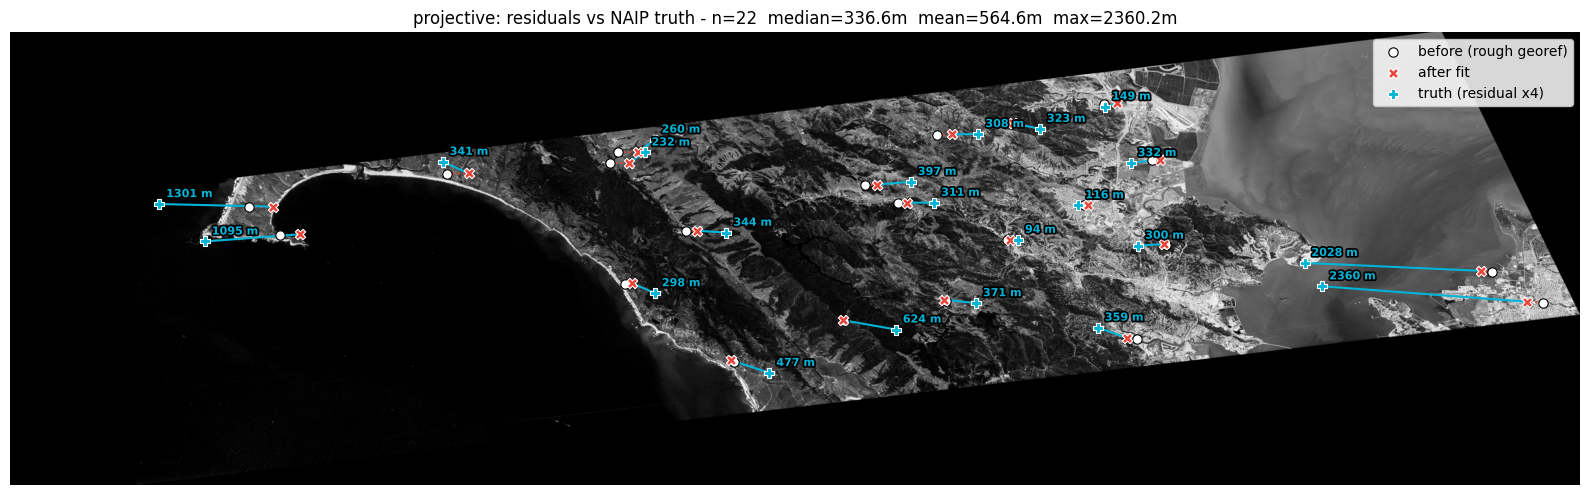

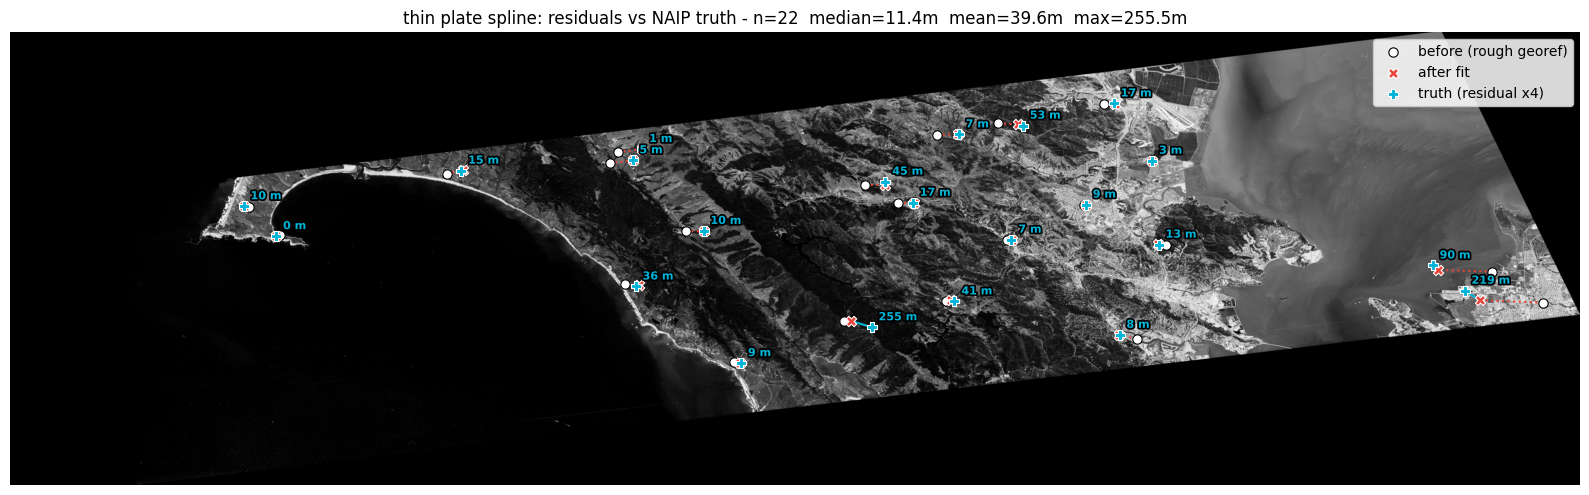

array([1.13305326e+00, 4.70285306e+00, 1.47453446e+01, 9.72964645e+00,
       1.55105568e-01, 8.88962826e+00, 2.55476497e+02, 4.12525928e+01,
       8.20445224e+00, 8.97546699e+01, 2.19470920e+02, 3.13135882e+00,
       1.69458261e+01, 5.34012231e+01, 7.09141879e+00, 4.49732399e+01,
       1.68081922e+01, 7.26270128e+00, 8.71541469e+00, 1.27259607e+01,
       1.00805983e+01, 3.55535462e+01])

In [9]:
original_points = read_points_csv(benchmark_corona_csv)
naip_points = read_points_csv(benchmark_naip_csv)

moved_points = apply_transform_to_points(
    benchmark_corona_csv, benchmark_moved_csv, corona_source_path, transform, naip_crs
)

# TPS takes the gcps directly - there is no fitted affine to pass in
tps_points = apply_tps_to_points(
    benchmark_corona_csv, benchmark_tps_csv, corona_source_path, gcps_thinned, naip_crs
)

before = compare_points(original_points, naip_points, label='before (rough corona georef):')
after = compare_points(moved_points, naip_points, label='after  (projective fit):     ')
tps = compare_points(tps_points, naip_points, label='after  (thin plate spline):  ')

display_benchmark_residuals(corona_source_path, original_points, moved_points, naip_points,
                            label='projective: ')
display_benchmark_residuals(corona_source_path, original_points, tps_points, naip_points,
                            label='thin plate spline: ')
